# Stochastic Gradient Descent: Theory, Noise & Convergence

## What is SGD?

Gradient Descent updates parameters using the gradient computed over the **entire dataset**:

$$\theta := \theta - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} \nabla_\theta J_i(\theta)$$

**Stochastic Gradient Descent** approximates this gradient using a **single random sample** at each step:

$$\theta := \theta - \alpha \cdot \nabla_\theta J_i(\theta)$$

where $i$ is drawn uniformly at random from the training set.

### Why SGD?
| Aspect | Batch GD | SGD |
|--------|----------|-----|
| **Gradient cost** | $O(m)$ per update | $O(1)$ per update |
| **Convergence path** | Smooth, deterministic | Noisy, stochastic |
| **Memory** | Needs full dataset | One sample at a time |
| **Escape shallow minima** | Poor | Good (noise helps) |
| **Final convergence** | Exact minimum | Oscillates near minimum |

### Variants
- **Batch GD**: full dataset gradient (deterministic).
- **Mini-batch GD**: gradient over a small random subset (compromise).
- **SGD**: single sample (most stochastic).

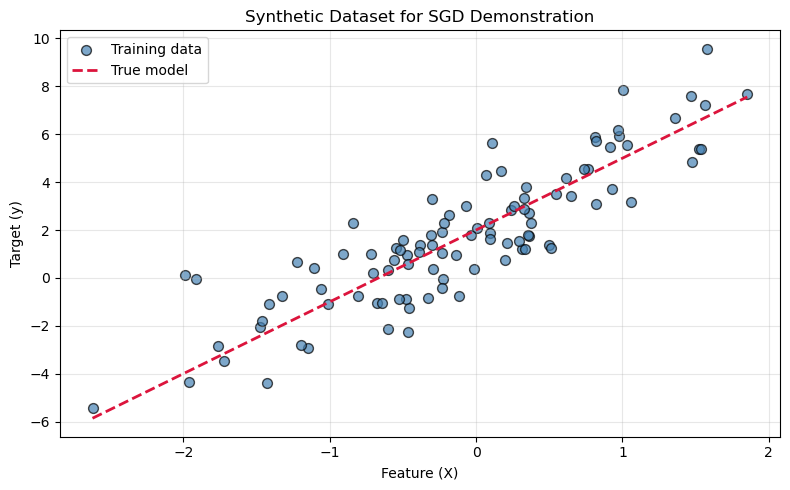

True parameters: intercept = 2.0, slope = 3.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Generate 1D regression data
n_samples = 100
X_raw = np.random.randn(n_samples, 1)
true_theta = np.array([2.0, 3.0])  # [intercept, slope]
X_b = np.c_[np.ones((n_samples, 1)), X_raw]
y = X_b @ true_theta + np.random.randn(n_samples) * 1.5

# For 2D visualization
x_line = np.linspace(X_raw.min(), X_raw.max(), 100)
X_line_b = np.c_[np.ones((100, 1)), x_line]

plt.figure(figsize=(8, 5))
plt.scatter(X_raw, y, c='steelblue', edgecolors='k', alpha=0.7, s=50, label='Training data')
plt.plot(x_line, X_line_b @ true_theta, color='crimson', linewidth=2, linestyle='--', label='True model')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('Synthetic Dataset for SGD Demonstration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("True parameters: intercept = {0}, slope = {1}".format(true_theta[0], true_theta[1]))


## 1. Batch Gradient Descent (Baseline)

Before introducing noise, we establish the deterministic baseline. Batch GD computes the exact gradient of the MSE loss over all $m$ samples:

$$\nabla J(\theta) = \frac{1}{m} X^T (X\theta - y)$$

Update:

$$\theta := \theta - \alpha \nabla J(\theta)$$

Because the loss is convex, Batch GD converges smoothly to the global minimum.


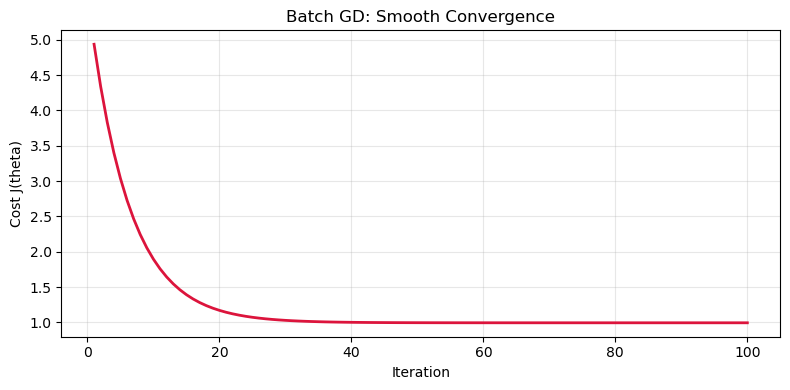

Batch GD estimate: intercept = 2.0107, slope = 2.7842


In [2]:
def batch_gd(X, y, lr=0.1, n_iter=100):
    """Batch Gradient Descent for linear regression."""
    m, p = X.shape
    theta = np.zeros(p)
    history = []
    for i in range(n_iter):
        grad = (1.0 / m) * X.T @ (X @ theta - y)
        theta -= lr * grad
        cost = (1.0 / (2.0 * m)) * np.sum((X @ theta - y)**2)
        history.append(cost)
    return theta, np.array(history)


theta_batch, cost_batch = batch_gd(X_b, y, lr=0.1, n_iter=100)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cost_batch) + 1), cost_batch, color='crimson', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost J(theta)')
plt.title('Batch GD: Smooth Convergence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Batch GD estimate: intercept = {0:.4f}, slope = {1:.4f}".format(theta_batch[0], theta_batch[1]))


## 2. Vanilla Stochastic Gradient Descent

In SGD, each update uses the gradient from a single randomly chosen sample:

$$\nabla J_i(\theta) = x_i (x_i^T \theta - y_i)$$

$$\theta := \theta - \alpha \cdot \nabla J_i(\theta)$$

### Characteristics
- **High variance**: the gradient of one sample is a very noisy estimate of the true gradient.
- **Fast initial progress**: each update is cheap, so many updates happen per epoch.
- **Oscillations**: the cost curve wiggles because some samples push the parameters in conflicting directions.

The plot below compares the cost-per-epoch of Batch GD and SGD. Note that SGD performs 100 updates per epoch while Batch GD performs only 1, yet the cost is computed on the full training set after each epoch for fair comparison.


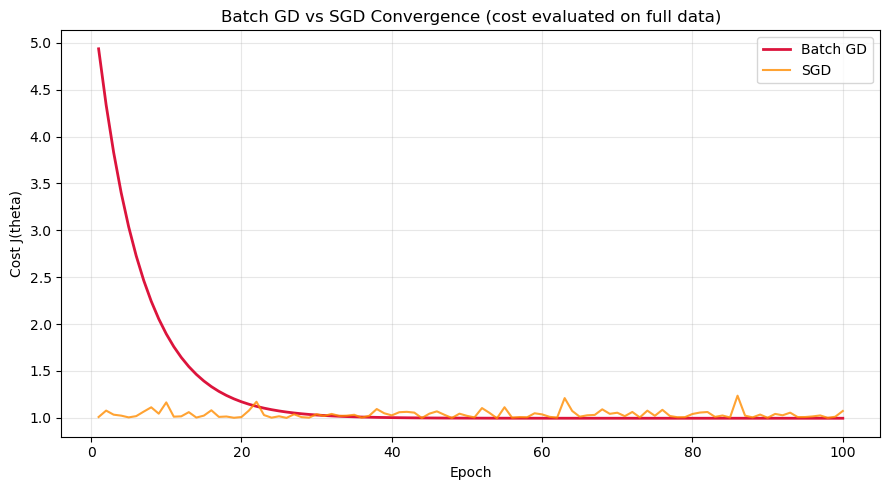

SGD estimate:    intercept = 1.6855, slope = 2.9906
Batch GD estimate: intercept = 2.0107, slope = 2.7842


In [3]:
def sgd(X, y, lr=0.1, n_epochs=50):
    """Vanilla Stochastic Gradient Descent."""
    m, p = X.shape
    theta = np.zeros(p)
    history = []
    for epoch in range(n_epochs):
        for i in range(m):
            idx = np.random.randint(m)
            xi = X[idx:idx+1]
            yi = y[idx:idx+1]
            grad = xi.T @ (xi @ theta - yi)
            theta -= lr * grad.flatten()
        cost = (1.0 / (2.0 * m)) * np.sum((X @ theta - y)**2)
        history.append(cost)
    return theta, np.array(history)


theta_sgd, cost_sgd = sgd(X_b, y, lr=0.05, n_epochs=100)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cost_batch) + 1), cost_batch, color='crimson', linewidth=2, label='Batch GD')
plt.plot(range(1, len(cost_sgd) + 1), cost_sgd, color='darkorange', linewidth=1.5, alpha=0.8, label='SGD')
plt.xlabel('Epoch')
plt.ylabel('Cost J(theta)')
plt.title('Batch GD vs SGD Convergence (cost evaluated on full data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("SGD estimate:    intercept = {0:.4f}, slope = {1:.4f}".format(theta_sgd[0], theta_sgd[1]))
print("Batch GD estimate: intercept = {0:.4f}, slope = {1:.4f}".format(theta_batch[0], theta_batch[1]))


## 3. Mini-Batch Gradient Descent

Mini-batch GD strikes a balance: it computes the gradient over a small random subset (e.g., 20 samples) rather than one or all.

$$\nabla J_{\text{batch}}(\theta) = \frac{1}{|B|} \sum_{i \in B} \nabla J_i(\theta)$$

| Method | Updates per epoch | Gradient variance | Computation per update |
|--------|-------------------|-------------------|------------------------|
| Batch GD | 1 | Zero | $O(m)$ |
| Mini-batch | $m / |B|$ | Moderate | $O(|B|)$ |
| SGD | $m$ | High | $O(1)$ |

Mini-batch is the default in deep learning frameworks because it leverages vectorized hardware while keeping noise levels useful.


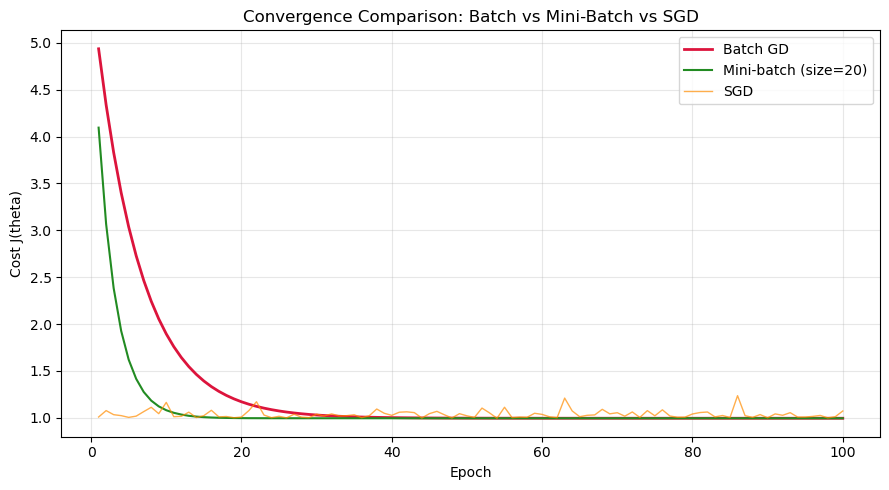

Mini-batch estimate: intercept = 2.0183, slope = 2.7845


In [4]:
def minibatch_gd(X, y, lr=0.1, n_epochs=50, batch_size=20):
    """Mini-batch Gradient Descent."""
    m, p = X.shape
    theta = np.zeros(p)
    history = []
    for epoch in range(n_epochs):
        indices = np.random.permutation(m)
        for start in range(0, m, batch_size):
            end = min(start + batch_size, m)
            batch_idx = indices[start:end]
            X_batch = X[batch_idx]
            y_batch = y[batch_idx]
            grad = (1.0 / len(batch_idx)) * X_batch.T @ (X_batch @ theta - y_batch)
            theta -= lr * grad
        cost = (1.0 / (2.0 * m)) * np.sum((X @ theta - y)**2)
        history.append(cost)
    return theta, np.array(history)


theta_mini, cost_mini = minibatch_gd(X_b, y, lr=0.05, n_epochs=100, batch_size=20)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cost_batch) + 1), cost_batch, color='crimson', linewidth=2, label='Batch GD')
plt.plot(range(1, len(cost_mini) + 1), cost_mini, color='forestgreen', linewidth=1.5, label='Mini-batch (size=20)')
plt.plot(range(1, len(cost_sgd) + 1), cost_sgd, color='darkorange', linewidth=1, alpha=0.7, label='SGD')
plt.xlabel('Epoch')
plt.ylabel('Cost J(theta)')
plt.title('Convergence Comparison: Batch vs Mini-Batch vs SGD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Mini-batch estimate: intercept = {0:.4f}, slope = {1:.4f}".format(theta_mini[0], theta_mini[1]))


## 4. Geometry of the Parameter Space

The loss landscape for linear regression is a convex paraboloid in parameter space. Batch GD descends smoothly along the steepest direction. SGD takes a random, zig-zagging path because each sample defines a different "noisy" loss surface.

The plots below show the 2D cost contours with the optimization trajectories superimposed. SGD's path is visibly stochastic, especially in the early epochs when the learning rate is large relative to the gradient noise.


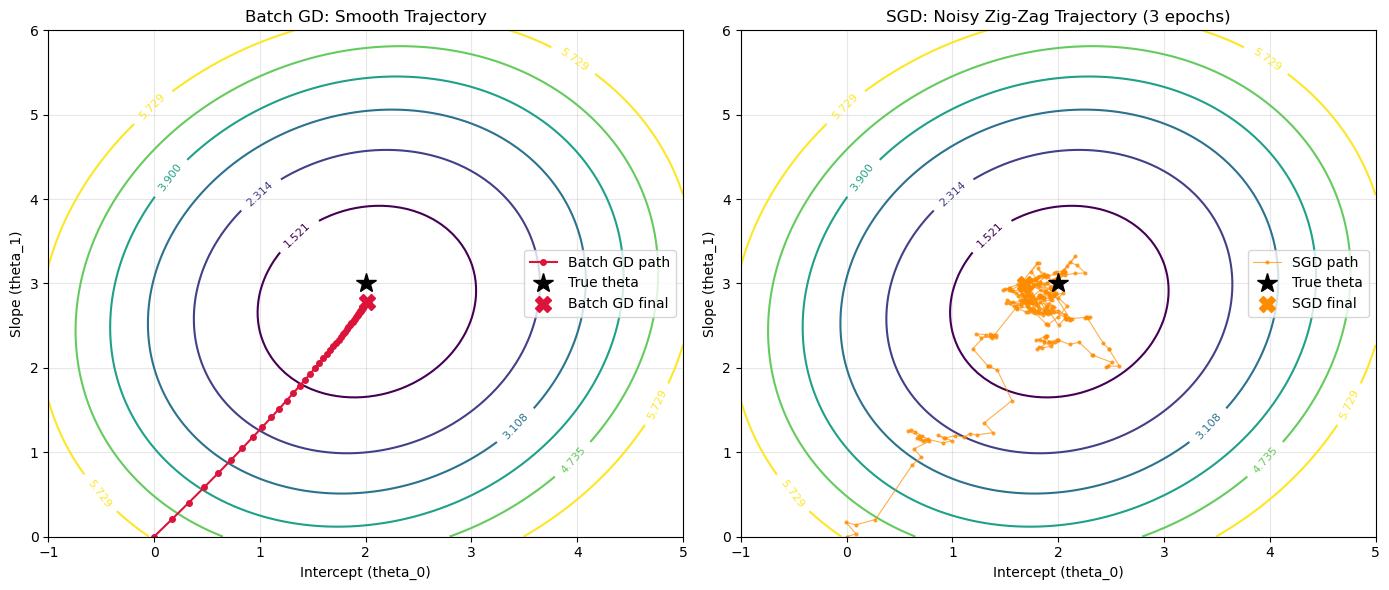

In [5]:
def sgd_trajectory(X, y, lr=0.05, n_epochs=3):
    """SGD that records theta after every single update."""
    m, p = X.shape
    theta = np.zeros(p)
    traj = [theta.copy()]
    for epoch in range(n_epochs):
        for i in range(m):
            idx = np.random.randint(m)
            xi = X[idx:idx+1]
            yi = y[idx:idx+1]
            grad = xi.T @ (xi @ theta - yi)
            theta -= lr * grad.flatten()
            traj.append(theta.copy())
    return np.array(traj)


def batch_gd_trajectory(X, y, lr=0.1, n_iter=50):
    """Batch GD that records theta after every iteration."""
    m, p = X.shape
    theta = np.zeros(p)
    traj = [theta.copy()]
    for i in range(n_iter):
        grad = (1.0 / m) * X.T @ (X @ theta - y)
        theta -= lr * grad
        traj.append(theta.copy())
    return np.array(traj)


# Cost surface grid
t0_vals = np.linspace(-1, 5, 100)
t1_vals = np.linspace(0, 6, 100)
T0, T1 = np.meshgrid(t0_vals, t1_vals)
J = np.zeros_like(T0)
m = len(y)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        t = np.array([T0[i, j], T1[i, j]])
        J[i, j] = (1.0 / (2.0 * m)) * np.sum((X_b @ t - y)**2)

traj_batch = batch_gd_trajectory(X_b, y, lr=0.1, n_iter=50)
traj_sgd = sgd_trajectory(X_b, y, lr=0.05, n_epochs=3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Batch GD path
ax = axes[0]
levels = np.percentile(J, [10, 25, 40, 55, 70, 85])
cs = ax.contour(T0, T1, J, levels=levels, cmap='viridis')
ax.clabel(cs, inline=True, fontsize=8)
ax.plot(traj_batch[:, 0], traj_batch[:, 1], 'o-', color='crimson', markersize=4, linewidth=1.5, label='Batch GD path')
ax.plot(true_theta[0], true_theta[1], '*', color='black', markersize=15, label='True theta')
ax.plot(theta_batch[0], theta_batch[1], 'X', color='crimson', markersize=12, label='Batch GD final')
ax.set_xlabel('Intercept (theta_0)')
ax.set_ylabel('Slope (theta_1)')
ax.set_title('Batch GD: Smooth Trajectory')
ax.legend()
ax.grid(True, alpha=0.3)

# SGD path
ax = axes[1]
cs = ax.contour(T0, T1, J, levels=levels, cmap='viridis')
ax.clabel(cs, inline=True, fontsize=8)
ax.plot(traj_sgd[:, 0], traj_sgd[:, 1], 'o-', color='darkorange', markersize=2, linewidth=0.8, alpha=0.7, label='SGD path')
ax.plot(true_theta[0], true_theta[1], '*', color='black', markersize=15, label='True theta')
ax.plot(theta_sgd[0], theta_sgd[1], 'X', color='darkorange', markersize=12, label='SGD final')
ax.set_xlabel('Intercept (theta_0)')
ax.set_ylabel('Slope (theta_1)')
ax.set_title('SGD: Noisy Zig-Zag Trajectory (3 epochs)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Learning Rate Impact

The learning rate $\alpha$ is critical in SGD:

- **Too large**: The noise in the gradient estimate causes divergence or heavy oscillation.
- **Too small**: Convergence is glacial; the algorithm may never reach the minimum in a reasonable number of epochs.
- **Just right**: Fast descent with tolerable oscillation near the minimum.

The plots below show SGD with three different learning rates on the same data and initialization.


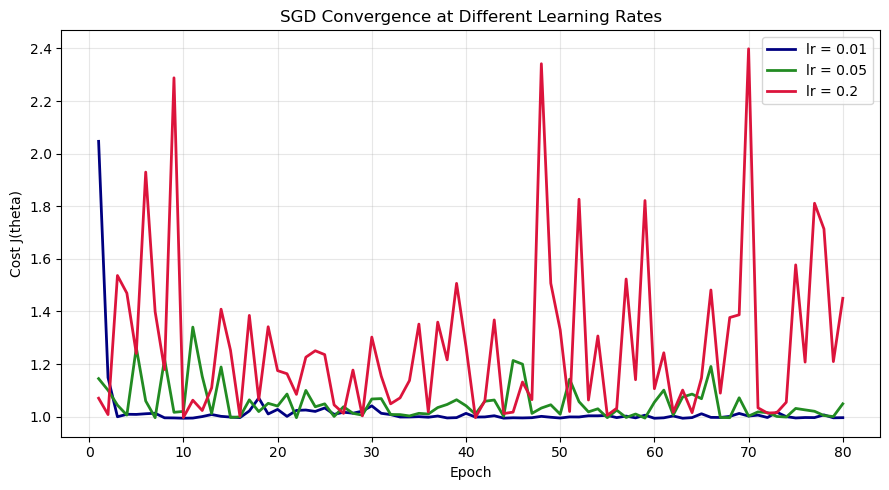

In [6]:
lrs = [0.01, 0.05, 0.2]
lr_colors = ['navy', 'forestgreen', 'crimson']

plt.figure(figsize=(9, 5))
for lr, color in zip(lrs, lr_colors):
    _, cost_hist = sgd(X_b, y, lr=lr, n_epochs=80)
    plt.plot(range(1, len(cost_hist) + 1), cost_hist, color=color, linewidth=2,
             label='lr = ' + str(lr))

plt.xlabel('Epoch')
plt.ylabel('Cost J(theta)')
plt.title('SGD Convergence at Different Learning Rates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Learning Rate Schedules

A constant learning rate forces a tradeoff: large $\alpha$ for fast early progress, small $\alpha$ for stable convergence. **Learning rate decay** solves this by shrinking $\alpha$ over time.

Common schedules:
1. **Step decay**: halve the learning rate every $k$ epochs.
2. **Exponential decay**: $\alpha_t = \alpha_0 e^{-\lambda t}$
3. **Inverse time decay**: $\alpha_t = \frac{\alpha_0}{1 + \lambda t}$

Decay helps SGD settle into a tighter minimum by reducing the oscillation radius as training progresses.


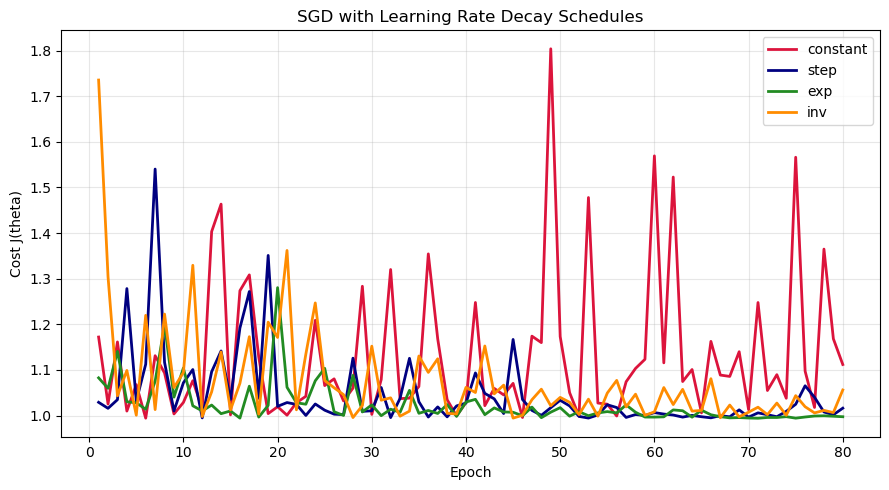

In [7]:
def sgd_scheduled(X, y, lr0=0.1, n_epochs=80, schedule='constant'):
    """SGD with various learning rate schedules."""
    m, p = X.shape
    theta = np.zeros(p)
    history = []
    for epoch in range(n_epochs):
        if schedule == 'step':
            lr = lr0 * (0.5 ** (epoch // 20))
        elif schedule == 'exp':
            lr = lr0 * np.exp(-0.05 * epoch)
        elif schedule == 'inv':
            lr = lr0 / (1.0 + 0.03 * epoch)
        else:
            lr = lr0
        
        for i in range(m):
            idx = np.random.randint(m)
            xi = X[idx:idx+1]
            yi = y[idx:idx+1]
            grad = xi.T @ (xi @ theta - yi)
            theta -= lr * grad.flatten()
        
        cost = (1.0 / (2.0 * m)) * np.sum((X @ theta - y)**2)
        history.append(cost)
    return theta, np.array(history)


schedules = ['constant', 'step', 'exp', 'inv']
sched_colors = ['crimson', 'navy', 'forestgreen', 'darkorange']

plt.figure(figsize=(9, 5))
for sched, color in zip(schedules, sched_colors):
    _, cost_hist = sgd_scheduled(X_b, y, lr0=0.1, n_epochs=80, schedule=sched)
    plt.plot(range(1, len(cost_hist) + 1), cost_hist, color=color, linewidth=2, label=sched)

plt.xlabel('Epoch')
plt.ylabel('Cost J(theta)')
plt.title('SGD with Learning Rate Decay Schedules')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. The Variance of SGD

Because SGD is stochastic, running it multiple times from the same initialization produces different final estimates. The variance decreases with more epochs and a smaller learning rate, but never fully vanishes.

The histogram below shows the distribution of the final slope estimate across 50 independent SGD runs (80 epochs each). The Batch GD estimate is shown as a vertical reference line.


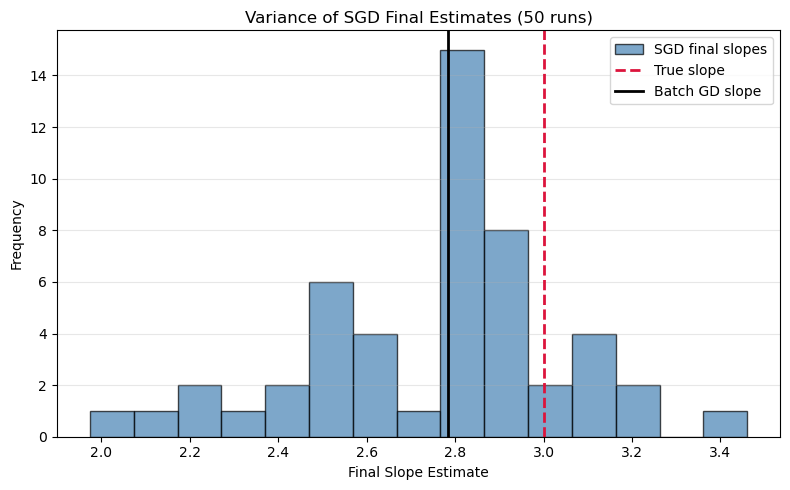

True slope:      3.0000
Batch GD slope:  2.7842
SGD mean slope:  2.7584
SGD std slope:   0.2900


In [8]:
n_runs = 50
sgd_slopes = []
for _ in range(n_runs):
    theta_run, _ = sgd(X_b, y, lr=0.05, n_epochs=80)
    sgd_slopes.append(theta_run[1])

sgd_slopes = np.array(sgd_slopes)

plt.figure(figsize=(8, 5))
plt.hist(sgd_slopes, bins=15, color='steelblue', edgecolor='black', alpha=0.7, label='SGD final slopes')
plt.axvline(true_theta[1], color='crimson', linestyle='--', linewidth=2, label='True slope')
plt.axvline(theta_batch[1], color='black', linestyle='-', linewidth=2, label='Batch GD slope')
plt.xlabel('Final Slope Estimate')
plt.ylabel('Frequency')
plt.title('Variance of SGD Final Estimates (50 runs)')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("True slope:      {0:.4f}".format(true_theta[1]))
print("Batch GD slope:  {0:.4f}".format(theta_batch[1]))
print("SGD mean slope:  {0:.4f}".format(np.mean(sgd_slopes)))
print("SGD std slope:   {0:.4f}".format(np.std(sgd_slopes)))


## Summary

| Property | Batch GD | Mini-Batch GD | SGD |
|----------|----------|---------------|-----|
| **Gradient source** | Full dataset | Random subset | Single sample |
| **Update cost** | $O(m)$ | $O(|B|)$ | $O(1)$ |
| **Convergence path** | Smooth | Slightly noisy | Very noisy |
| **Memory footprint** | Full data | One batch | One sample |
| **Typical use** | Small datasets | Deep learning | Online learning |

### Key Takeaways
- SGD trades gradient accuracy for computational speed. One cheap, noisy step is often better than one expensive exact step.
- The **learning rate** is the most important hyperparameter; decay schedules are essential for stable convergence.
- **Mini-batch GD** (e.g., batch size 32-512) is the practical standard in modern ML because it balances noise and vectorization.
- SGD's noise is not purely a bug — it acts as implicit regularization and helps escape sharp local minima in non-convex landscapes.